In [6]:
import pandas as pd

In [34]:
# Load data
matches = pd.read_csv('data/Match.csv')
characters = pd.read_csv('data/Character.csv')

# Define blacklist of player IDs to exclude from analysis (empty by default)
blacklist = []

# Display shape and first few rows
print(f"Matches shape: {matches.shape}")
print(f"Characters shape: {characters.shape}")
print(f"Blacklisted player IDs: {blacklist}")
print(f"\nMatches with ranked=1: {matches['ranked'].notna().sum()}")
print("\nFirst few matches:")
print(matches.head())


Matches shape: (11991, 9)
Characters shape: (17, 2)
Blacklisted player IDs: []

Matches with ranked=1: 2673

First few matches:
   id  threadId  ladderResetId  winnerId  winnerCharacterId  loserId  \
0   1       NaN              1         1                  1        2   
1   2       NaN              1         3                  1        4   
2   3       NaN              1         3                  4        4   
3   4       NaN              1         2                  2        1   
4   5       NaN              1         3                  4        5   

   loserCharacterId  ranked     finishedAt  
0                 2     NaN  1743949725369  
1                 3     NaN  1743949956544  
2                 5     NaN  1743950160505  
3                 1     NaN  1743950246134  
4                 1     NaN  1743950784872  


In [35]:
# Filter for ladderResetId == 22, ranked matches only, and exclude blacklisted players
ladder_22 = matches[
    (matches['ladderResetId'] == 22) & 
    # (matches['ranked'].notna()) &
    (~matches['winnerId'].isin(blacklist)) &
    (~matches['loserId'].isin(blacklist))
].copy()
print(f"Matches with ladderResetId 22 (ranked, blacklist applied): {len(ladder_22)}")

# Merge with character names for better readability
ladder_22 = ladder_22.merge(characters, left_on='winnerCharacterId', right_on='id', how='left')
ladder_22 = ladder_22.merge(characters, left_on='loserCharacterId', right_on='id', how='left', suffixes=('_winner', '_loser'))

# Calculate win rates for each character
winner_counts = ladder_22['name_winner'].value_counts()
loser_counts = ladder_22['name_loser'].value_counts()
all_chars = set(winner_counts.index) | set(loser_counts.index)

win_rates = {}
for char in all_chars:
    wins = winner_counts.get(char, 0)
    losses = loser_counts.get(char, 0)
    total = wins + losses
    win_rate = (wins / total * 100) if total > 0 else 0
    win_rates[char] = {'wins': wins, 'losses': losses, 'total': total, 'win_rate': win_rate}

# Sort by win rate (descending)
sorted_chars = sorted(win_rates.items(), key=lambda x: x[1]['win_rate'], reverse=True)
sorted_char_names = [char for char, _ in sorted_chars]

print("\nCharacter Win Rates (sorted):")
for char, stats in sorted_chars:
    print(f"{char:12} - WR: {stats['win_rate']:5.1f}% ({stats['wins']:3d}W-{stats['losses']:3d}L)")

# Create a pivot table and reorder by win rate
win_matrix = ladder_22.groupby(['name_winner', 'name_loser']).size().unstack(fill_value=0)
win_matrix = win_matrix.reindex(sorted_char_names, axis=0).reindex(sorted_char_names, axis=1)
print("\nWin matrix shape:", win_matrix.shape)


Matches with ladderResetId 22 (ranked, blacklist applied): 3324

Character Win Rates (sorted):
Frieren      - WR:  57.9% (289W-210L)
Denken       - WR:  57.7% (192W-141L)
Methode      - WR:  57.4% (276W-205L)
Fern         - WR:  57.0% (281W-212L)
Edel         - WR:  55.6% (193W-154L)
Sense        - WR:  52.6% (160W-144L)
Stark        - WR:  52.1% (202W-186L)
Laufen       - WR:  50.0% (183W-183L)
Übel         - WR:  49.6% (288W-293L)
Wirbel       - WR:  47.9% (195W-212L)
Sein         - WR:  46.9% (105W-119L)
Serie        - WR:  46.5% (213W-245L)
Flamme       - WR:  46.4% (199W-230L)
Linie        - WR:  45.1% (224W-273L)
Himmel       - WR:  43.8% ( 84W-108L)
Aura         - WR:  39.1% (184W-286L)
Stille       - WR:  31.3% ( 56W-123L)

Win matrix shape: (17, 17)


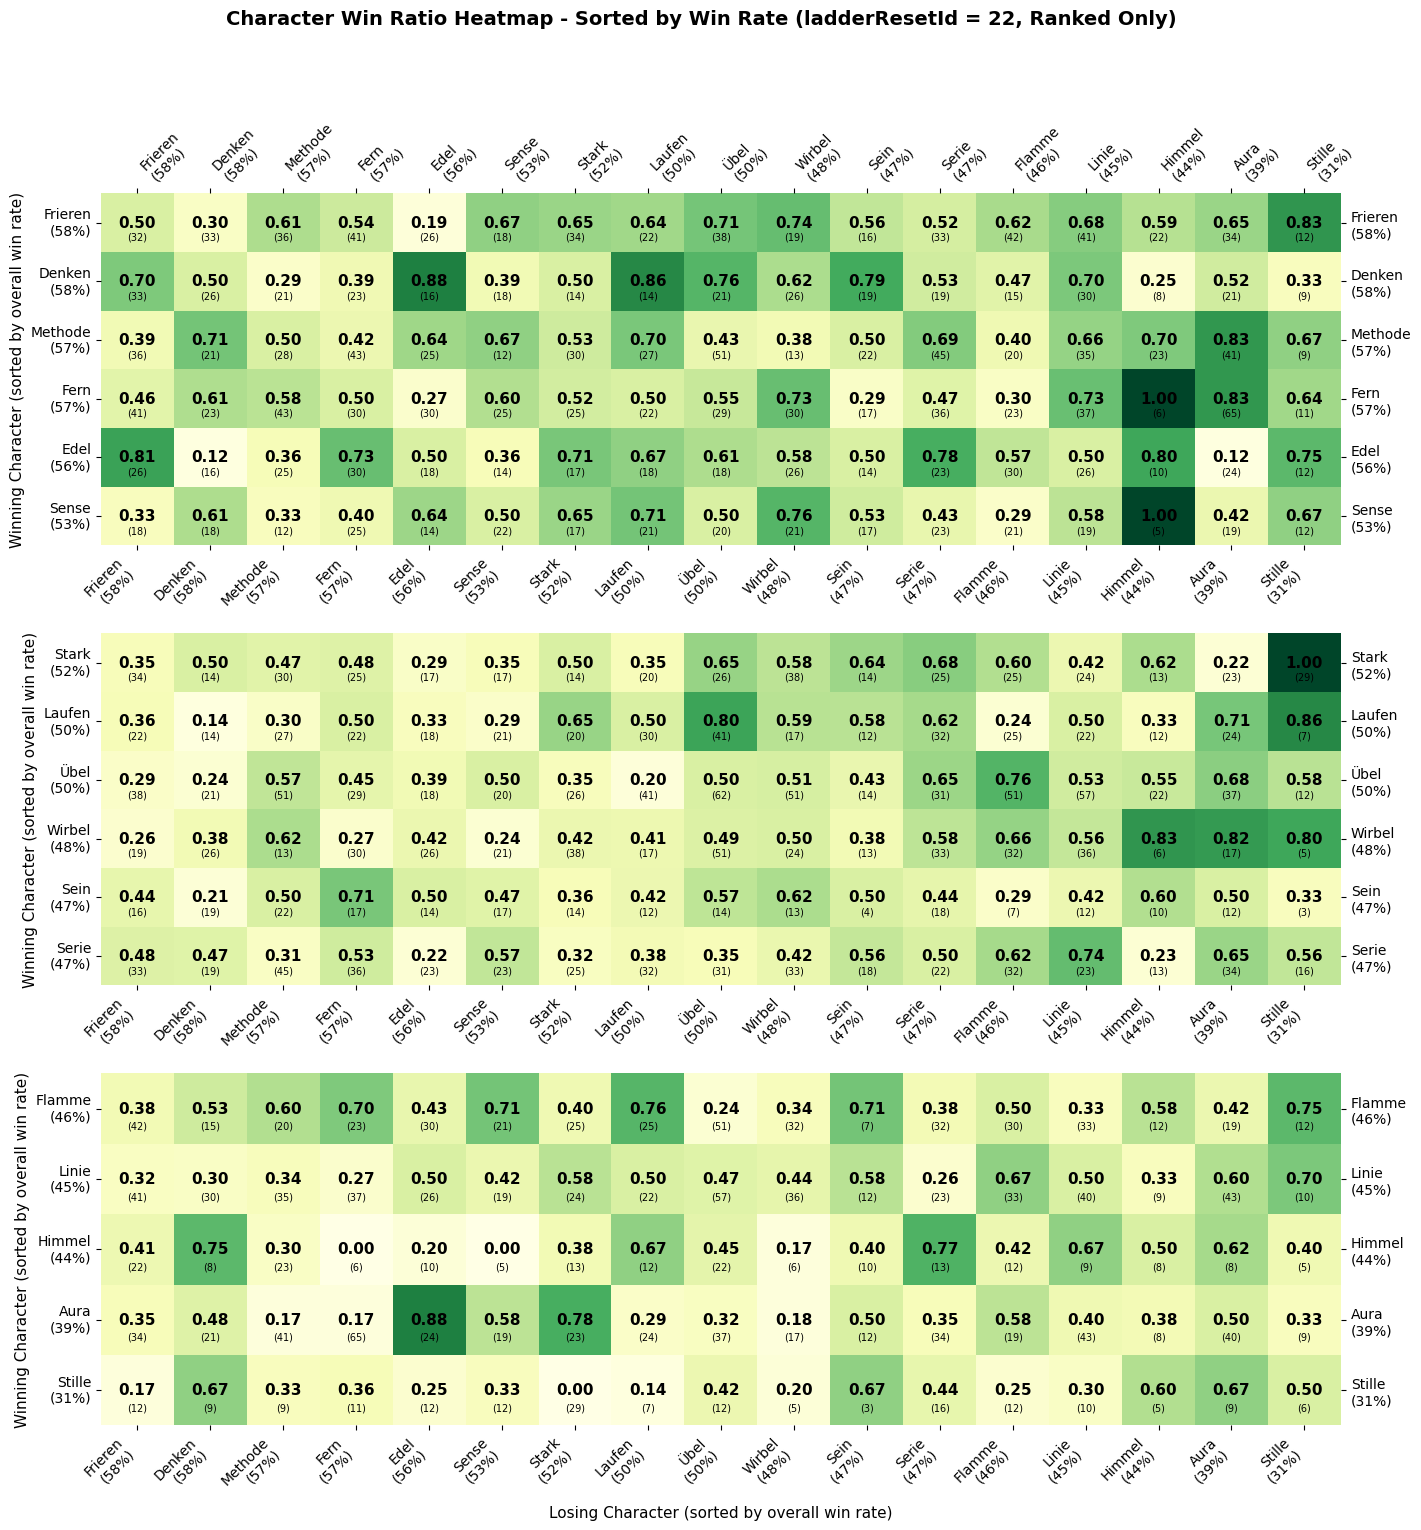

Win Ratio Matrix with Total Games:

Ratios (2 decimal places):
name_loser   Frieren  Denken  Methode  Fern  Edel  Sense  Stark  Laufen  Übel  \
name_winner                                                                     
Frieren         0.50    0.30     0.61  0.54  0.19   0.67   0.65    0.64  0.71   
Denken          0.70    0.50     0.29  0.39  0.88   0.39   0.50    0.86  0.76   
Methode         0.39    0.71     0.50  0.42  0.64   0.67   0.53    0.70  0.43   
Fern            0.46    0.61     0.58  0.50  0.27   0.60   0.52    0.50  0.55   
Edel            0.81    0.12     0.36  0.73  0.50   0.36   0.71    0.67  0.61   
Sense           0.33    0.61     0.33  0.40  0.64   0.50   0.65    0.71  0.50   
Stark           0.35    0.50     0.47  0.48  0.29   0.35   0.50    0.35  0.65   
Laufen          0.36    0.14     0.30  0.50  0.33   0.29   0.65    0.50  0.80   
Übel            0.29    0.24     0.57  0.45  0.39   0.50   0.35    0.20  0.50   
Wirbel          0.26    0.38     0.62  0.27  0

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import PowerNorm

# Convert win counts to win ratios (wins / total games)
win_ratio_matrix = pd.DataFrame(index=win_matrix.index, columns=win_matrix.columns, dtype=float)
total_games_matrix = pd.DataFrame(index=win_matrix.index, columns=win_matrix.columns, dtype=int)

for winner in win_matrix.index:
    for loser in win_matrix.columns:
        wins = win_matrix.loc[winner, loser]
        # Calculate total games this matchup (winner vs loser + loser vs winner)
        total_games = wins + win_matrix.loc[loser, winner]
        ratio = (wins / total_games) if total_games > 0 else 0
        win_ratio_matrix.loc[winner, loser] = ratio
        total_games_matrix.loc[winner, loser] = total_games

# Create custom labels with win rates
y_labels = [f"{char}\n({stats['win_rate']:.0f}%)" for char, stats in sorted_chars]
x_labels = [f"{char}\n({stats['win_rate']:.0f}%)" for char, stats in sorted_chars]

# Split into 3 parts
num_rows = len(win_ratio_matrix)
part1_end = 6
part2_end = 12

parts = [
    (0, part1_end, "both"),      # Part 1: rows 0-5, labels on both top and bottom
    (part1_end, part2_end, "bottom"),  # Part 2: rows 6-11, labels on bottom
    (part2_end, num_rows, "bottom")       # Part 3: rows 12-16, labels on bottom
]

fig, axes = plt.subplots(3, 1, figsize=(16, 16), gridspec_kw={'hspace': 0.25})

for part_idx, (start_row, end_row, label_pos) in enumerate(parts):
    ax = axes[part_idx]
    data_subset = win_ratio_matrix.iloc[start_row:end_row, :]
    
    norm = PowerNorm(gamma=2.0, vmin=0, vmax=1)
    sns.heatmap(data_subset, annot=False, cmap='YlGn', cbar=False,
                norm=norm, ax=ax)
    
    # Add annotations
    for i, winner in enumerate(data_subset.index):
        for j, loser in enumerate(data_subset.columns):
            ratio = win_ratio_matrix.loc[winner, loser]
            total = int(total_games_matrix.loc[winner, loser])
            ax.text(j + 0.5, i + 0.50, f"{ratio:.2f}", ha="center", va="center", color="black", fontsize=11, fontweight='bold')
            ax.text(j + 0.5, i + 0.75, f"({total})", ha="center", va="center", color="black", fontsize=7)
    
    # Setup axes
    ax.set_ylabel('Winning Character (sorted by overall win rate)', fontsize=11)
    subset_y_labels = y_labels[start_row:end_row]
    ax.set_yticklabels(subset_y_labels, rotation=0, fontsize=10)
    
    if label_pos == "both":  # First part - labels on both top and bottom
        ax.set_xlabel('')
        # Show bottom labels
        ax.xaxis.tick_bottom()
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=10)
        # Add top labels via secondary axis
        ax_top = ax.twiny()
        ax_top.set_xticks(np.arange(len(x_labels)) + 0.5)
        ax_top.set_xticklabels(x_labels, rotation=45, ha='left', fontsize=10)
        ax_top.set_xlim(ax.get_xlim())
        ax_top.spines['top'].set_visible(False)
        ax_top.spines['bottom'].set_visible(False)
        ax_top.spines['left'].set_visible(False)
        ax_top.spines['right'].set_visible(False)
    else:  # Other parts - labels on bottom only
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=10)
        ax.xaxis.tick_bottom()
    
    if part_idx == 2:  # Only show x label on last part
        ax.set_xlabel('Losing Character (sorted by overall win rate)', fontsize=11)
    else:
        ax.set_xlabel('')
    
    # Add side labels
    ax_right = ax.twinx()
    ax_right.set_yticks(np.arange(len(subset_y_labels)) + 0.5)
    ax_right.set_yticklabels(subset_y_labels, rotation=0, fontsize=10)
    ax_right.set_ylim(ax.get_ylim())
    ax_right.spines['top'].set_visible(False)
    ax_right.spines['bottom'].set_visible(False)
    ax_right.spines['left'].set_visible(False)
    ax_right.spines['right'].set_visible(False)

fig.suptitle('Character Win Ratio Heatmap - Sorted by Win Rate (ladderResetId = 22, Ranked Only)', 
             fontsize=14, fontweight='bold', y=0.995)

plt.show()

print("Win Ratio Matrix with Total Games:")
print("\nRatios (2 decimal places):")
print(win_ratio_matrix.round(2))
print("\nTotal Games per Matchup:")
print(total_games_matrix)
